# 生成 4 张图
## 图 1

根据在正常环境下用 Wireshark 抓取得到的 .csv 文件绘制折线图。将 x 轴标为时间，y 轴标为数据包数量。文件名需自行填写。


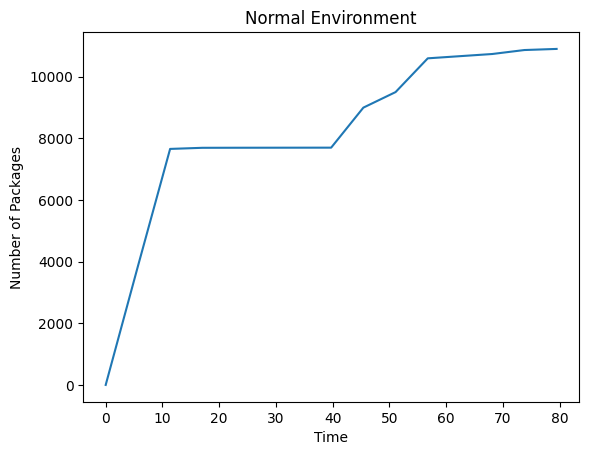

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取正常环境数据
data=pd.read_csv('normal.csv')
time = data['Time'].values
no = data['No.'].values
step = time[-1]/15
x = np.arange(0,time[-1],step)
count = 0
section = step
y = [0]
for i in time:
    if float(i) > section:
        y.append(no[count])
        section = section + step
    if len(y) == len(x):
        break
    count = count + 1 

plt.plot(x,y)
plt.title('Normal Environment')
plt.xlabel('Time')
plt.ylabel('Number of Packages')
plt.show()

 ## 图 2
根据在 DDoS 攻击环境下用 Wireshark 抓取得到的 .csv 文件绘制折线图。将 x 轴标为时间，y 轴标为数据包数量。文件名需自行填写。


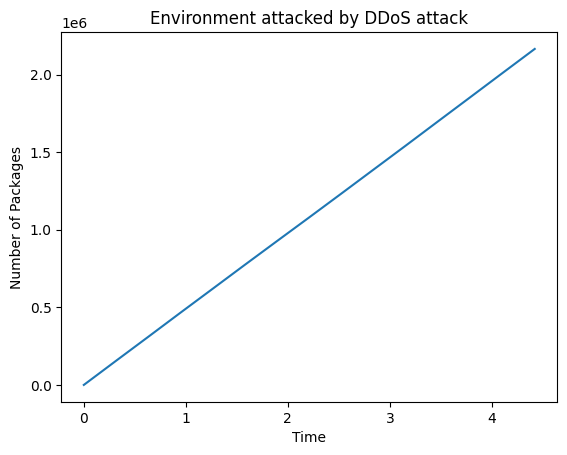

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取 DDoS 攻击环境数据
data=pd.read_csv('ddos_syn_flood_lo.csv')
time = data['Time'].values
no = data['No.'].values
step = time[-1]/15
x = np.arange(0,time[-1],step)
count = 0
section = step
y = [0]
for i in time:
    if float(i) > section:
        y.append(no[count])
        section = section + step
    if len(y) == len(x):
        break
    count = count + 1 

plt.plot(x,y)
plt.title('Environment attacked by DDoS attack')
plt.xlabel('Time')
plt.ylabel('Number of Packages')
plt.show()

## 图 3
根据在正常环境下用 Wireshark 抓取得到的 .csv 文件绘制柱状图。将 x 轴标为时间（7 个时间区间，0–3.5秒），y 轴标为 TCP 数据包数量。文件名需自行填写。


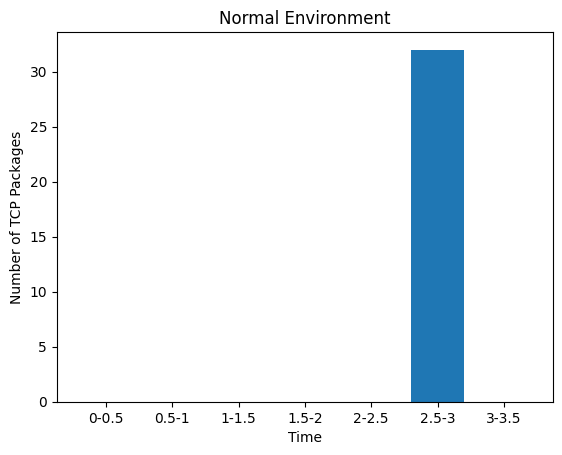

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取正常环境数据
data=pd.read_csv('normal.csv')
time = data['Time'].values
protocol = data['Protocol'].values
x = ['0-0.5','0.5-1','1-1.5','1.5-2','2-2.5','2.5-3','3-3.5']
count_y = 0
section = 0.5
y = []

# 遍历所有数据包
for i in range(len(time)):
    # 检查是否进入下一个时间区间
    # 使用 while 循环处理时间跨度较大的情况
    while time[i] > section:
        y.append(count_y)
        section = section + 0.5
        count_y = 0
        if len(y) == len(x):
            break
            
    if len(y) == len(x):
        break
        
    # 统计 TCP 包
    if protocol[i] == 'TCP':
        count_y = count_y + 1

# 如果数据结束了但 y 还没填满，用 0 填充剩余区间 (或者填充最后一个计数)
while len(y) < len(x):
    y.append(count_y)
    count_y = 0 # 之后的区间计数为 0
    section += 0.5

plt.bar(x, y, align = 'center')
plt.title('Normal Environment')
plt.xlabel('Time')
plt.ylabel('Number of TCP Packages')
plt.show()

## 图 4
根据在 DDoS 攻击环境下用 Wireshark 抓取得到的 .csv 文件绘制柱状图。将 x 轴标为时间（7 个时间区间，0–3.5秒），y 轴标为 TCP 数据包数量。文件名需自行填写。

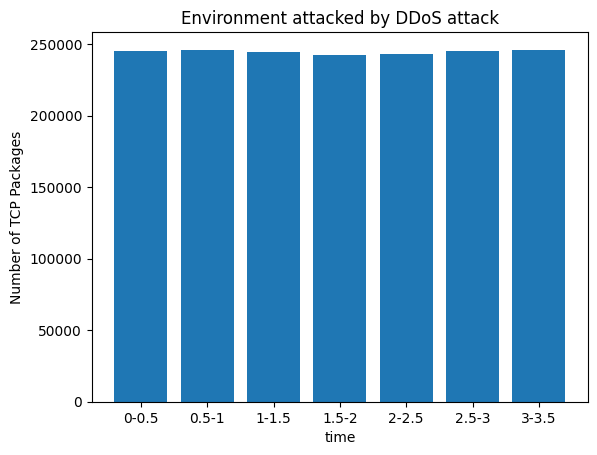

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取 DDoS 攻击环境数据
data=pd.read_csv('ddos_syn_flood_lo.csv')
time = data['Time'].values
protocol = data['Protocol'].values
x = ['0-0.5','0.5-1','1-1.5','1.5-2','2-2.5','2.5-3','3-3.5']
count_y = 0
section = 0.5
y = []

# 遍历所有数据包
for i in range(len(time)):
    # 检查是否进入下一个时间区间
    while time[i] > section:
        y.append(count_y)
        section = section + 0.5
        count_y = 0
        if len(y) == len(x):
            break
            
    if len(y) == len(x):
        break
        
    # 统计 TCP 包
    if protocol[i] == 'TCP':
        count_y = count_y + 1

# 填充剩余区间
while len(y) < len(x):
    y.append(count_y)
    count_y = 0
    section += 0.5

plt.bar(x, y, align = 'center')
plt.title('Environment attacked by DDoS attack')
plt.xlabel('time')
plt.ylabel('Number of TCP Packages')
plt.show()

# 更多分析
## 协议分布对比 (Protocol Distribution)
比较正常环境与 DDoS 攻击环境下的协议分布情况。

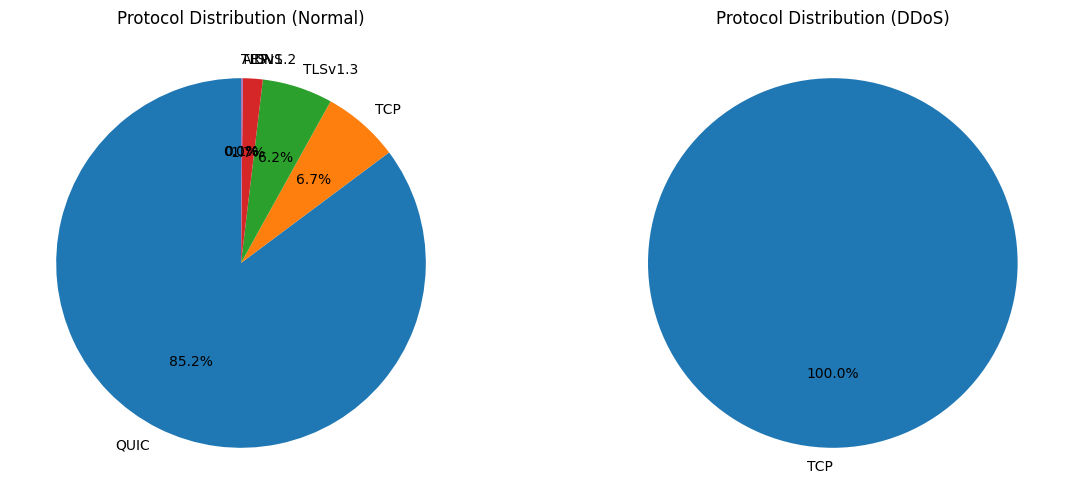

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据 (请确保 csv 文件在同一目录下)
# 如果文件名为其他名称，请修改此处
try:
    df_normal = pd.read_csv('normal.csv')
    df_ddos = pd.read_csv('ddos_syn_flood_lo.csv')

    # 统计协议数量
    normal_protocols = df_normal['Protocol'].value_counts()
    ddos_protocols = df_ddos['Protocol'].value_counts()

    # 绘制饼图
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 正常环境
    axes[0].pie(normal_protocols, labels=normal_protocols.index, autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Protocol Distribution (Normal)')

    # DDoS 环境
    # 如果协议种类过多，只显示前 5 个，其他的合并为 'Other'
    if len(ddos_protocols) > 5:
        top_5 = ddos_protocols.head(5)
        other = pd.Series({'Other': ddos_protocols.iloc[5:].sum()})
        ddos_protocols_plot = pd.concat([top_5, other])
    else:
        ddos_protocols_plot = ddos_protocols

    axes[1].pie(ddos_protocols_plot, labels=ddos_protocols_plot.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Protocol Distribution (DDoS)')

    plt.show()
except FileNotFoundError as e:
    print(f"Error: {e}. Please check file names.")

## 数据包长度分布对比 (Packet Length Distribution)
比较正常环境与 DDoS 攻击环境下的数据包长度分布。DDoS 攻击（如 SYN Flood）通常会有大量小包。

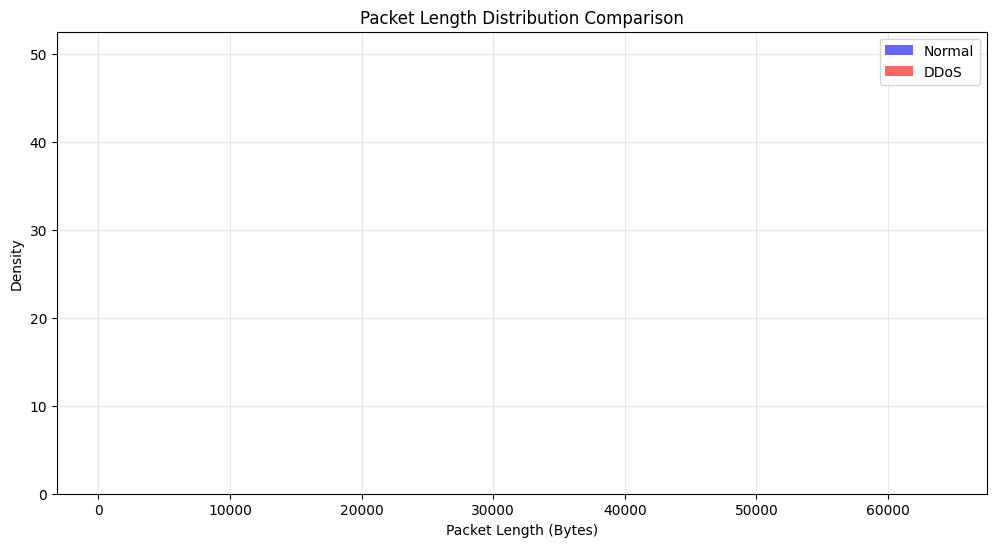

In [8]:
import matplotlib.pyplot as plt

# 绘制直方图
plt.figure(figsize=(12, 6))

# 使用 density=True 进行归一化，以便比较不同数据量级的分布
plt.hist(df_normal['Length'], bins=50, alpha=0.6, label='Normal', density=True, color='blue')
plt.hist(df_ddos['Length'], bins=50, alpha=0.6, label='DDoS', density=True, color='red')

plt.title('Packet Length Distribution Comparison')
plt.xlabel('Packet Length (Bytes)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## DDoS 攻击源 IP 分析 (Top Source IPs in DDoS)
分析 DDoS 攻击中最活跃的源 IP 地址。

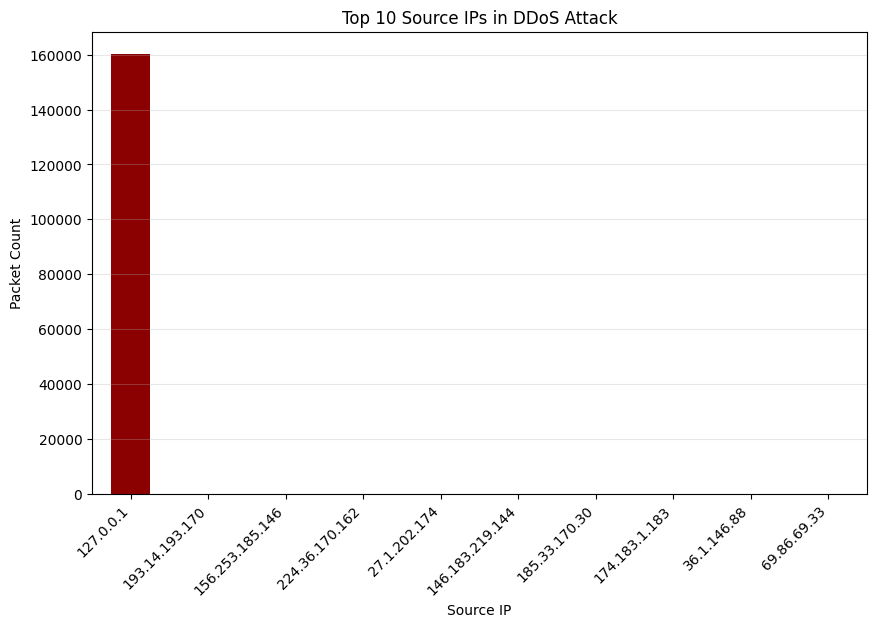

In [9]:
# 统计 DDoS 数据集中出现频率最高的 10 个源 IP
top_sources_ddos = df_ddos['Source'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_sources_ddos.plot(kind='bar', color='darkred')
plt.title('Top 10 Source IPs in DDoS Attack')
plt.xlabel('Source IP')
plt.ylabel('Packet Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()

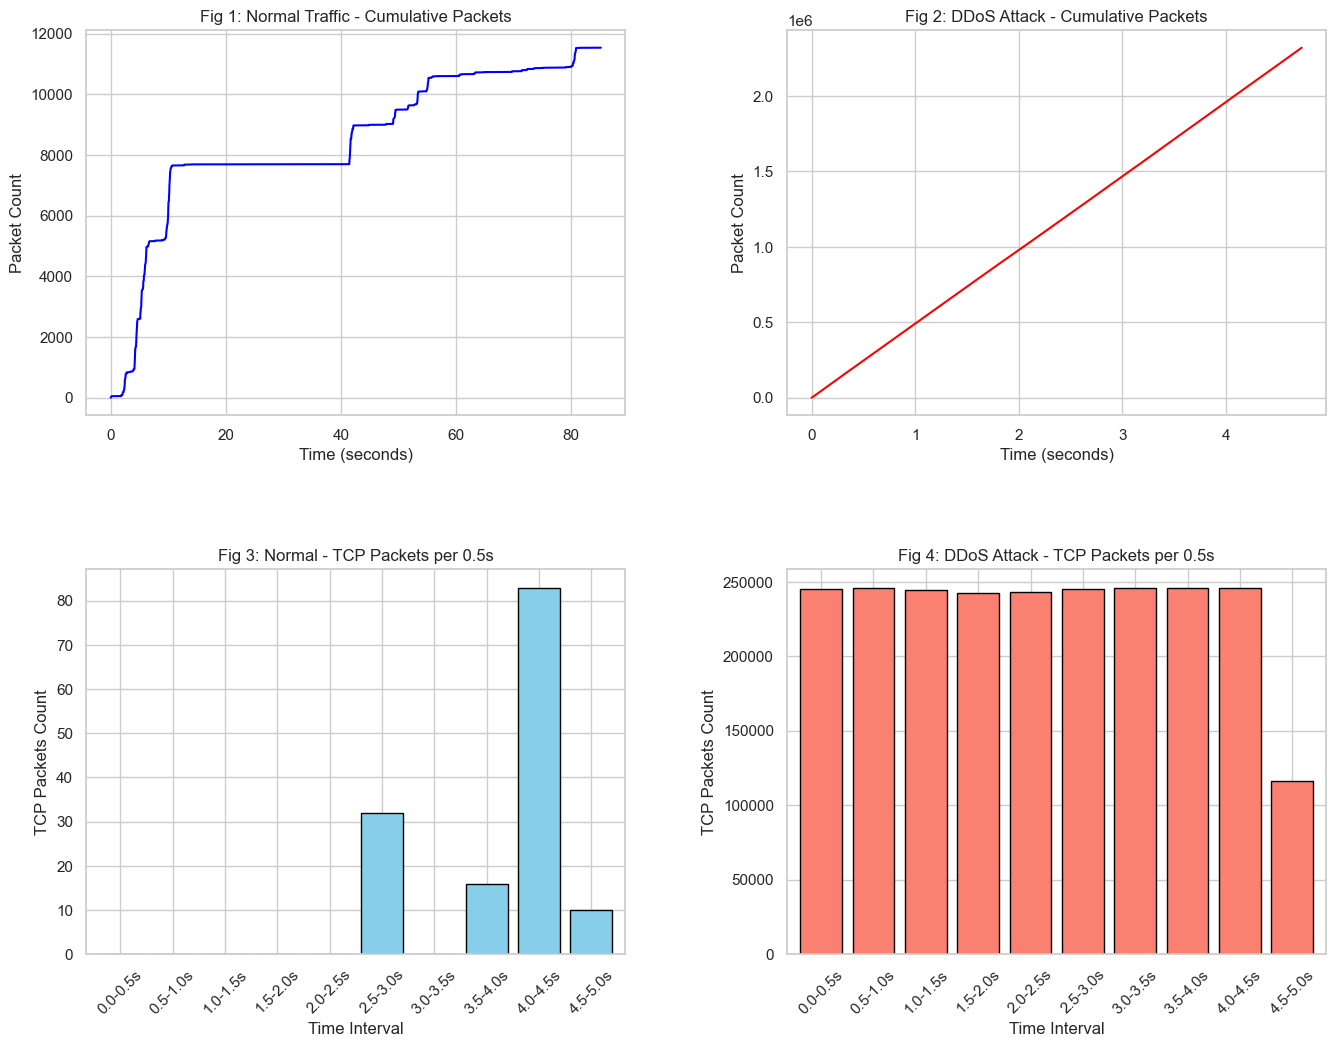

C:\Users\kenny\AppData\Local\Temp\ipykernel_6920\2988688825.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Normal', 'Attack'], y=[unique_ips_normal, unique_ips_attack],
C:\Users\kenny\AppData\Local\Temp\ipykernel_6920\2988688825.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_attack_ips.values, y=top_attack_ips.index, ax=ax_adv[2], palette="Reds_r")


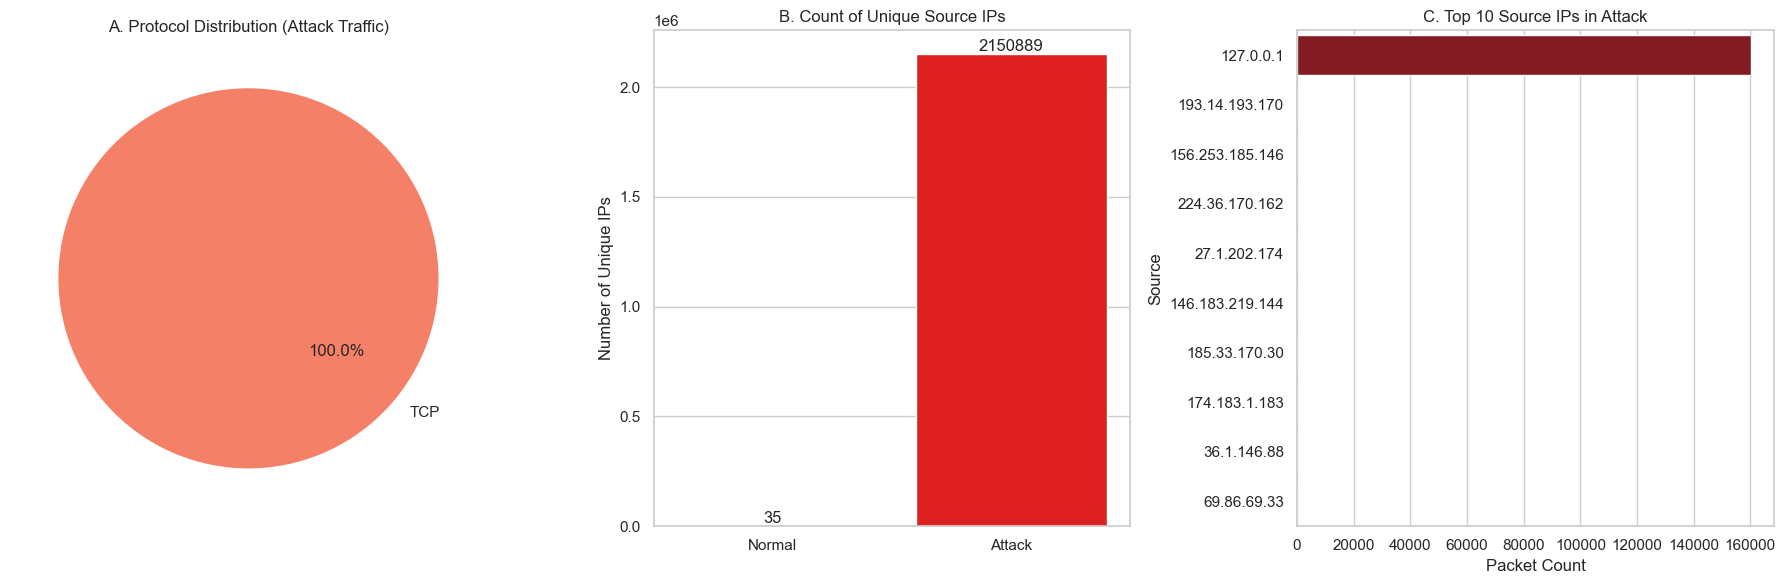

In [3]:
# --------------------------------------------------------------------------------
# 第一部分：優化後的基礎 4 張圖代碼
# 這段代碼將取代您原有的四段代碼。它更簡潔、執行速度更快，並且自動處理時間區間聚合。
# 使用說明：
# 1. 將 normal_file 和 attack_file 替換為您的真實檔名（例如 normal.csv, attack.csv）。
# 2. 這段代碼會一次性生成您要求的 4 張圖。
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 設定圖表風格
sns.set(style="whitegrid")

# ==========================================
# 請在此處填寫您的檔案名稱
# ==========================================
normal_file = 'normal.csv'  # 替換為您的正常流量檔名
attack_file = 'ddos_syn_flood_lo.csv'  # 替換為您的攻擊流量檔名

def load_and_process(filename):
    """讀取 CSV 並進行預處理"""
    try:
        # 讀取 CSV
        df = pd.read_csv(filename)
        # 確保 Time 欄位是數值型別 (處理可能出現的非數值錯誤)
        df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
        # 確保 No. 欄位是數值
        df['No.'] = pd.to_numeric(df['No.'], errors='coerce')
        return df
    except FileNotFoundError:
        print(f"錯誤: 找不到檔案 {filename}，請檢查路徑與檔名。")
        return None

# 讀取數據
df_normal = load_and_process(normal_file)
df_attack = load_and_process(attack_file)

if df_normal is not None and df_attack is not None:
    
    # 建立畫布：2x2 排列 (這就是之前報錯的地方，我們現在要解開它)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 將 2x2 的矩陣攤平，變成 [圖1, 圖2, 圖3, 圖4]，方便我們呼叫
    ax = axes.flatten() 
    
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    # --- 圖 1: 正常環境 (折線圖) ---
    # 使用 Time 作為 X 軸，累積封包數(No.) 作為 Y 軸
    ax[0].plot(df_normal['Time'], df_normal['No.'], color='blue', linewidth=1.5)
    ax[0].set_title('Fig 1: Normal Traffic - Cumulative Packets')
    ax[0].set_xlabel('Time (seconds)')
    ax[0].set_ylabel('Packet Count')

    # --- 圖 2: DDoS 攻擊環境 (折線圖) ---
    ax[1].plot(df_attack['Time'], df_attack['No.'], color='red', linewidth=1.5)
    ax[1].set_title('Fig 2: DDoS Attack - Cumulative Packets')
    ax[1].set_xlabel('Time (seconds)')
    ax[1].set_ylabel('Packet Count')

    # --- 定義繪製柱狀圖的函數 (優化效能，不使用 for 迴圈) ---
    def plot_tcp_bar(df, axis_obj, title, bar_color):
        # 1. 篩選出 TCP 協定的封包
        tcp_df = df[df['Protocol'] == 'TCP'].copy()
        
        if len(tcp_df) > 0:
            # 2. 建立 0.5 秒的時間區間 (bins)
            max_time = df['Time'].max()
            bins = np.arange(0, max_time + 1, 0.5) # 每 0.5 秒切一刀
            
            # 3. 統計每個區間的封包數
            # 使用 pd.cut 將時間分組
            time_groups = pd.cut(tcp_df['Time'], bins=bins)
            counts = time_groups.value_counts().sort_index()
            
            # 4. 繪圖
            # 取前 7 個區間 (配合題目要求 0-3.5秒，或顯示更多)
            counts.head(10).plot(kind='bar', ax=axis_obj, color=bar_color, width=0.8, edgecolor='black')
            
            # 調整標籤
            labels = [f"{b.left:.1f}-{b.right:.1f}s" for b in counts.head(10).index]
            axis_obj.set_xticklabels(labels, rotation=45)
            axis_obj.set_title(title)
            axis_obj.set_xlabel('Time Interval')
            axis_obj.set_ylabel('TCP Packets Count')
        else:
            axis_obj.text(0.5, 0.5, 'No TCP Packets Found', ha='center')

    # --- 圖 3: 正常環境 (TCP 柱狀圖) ---
    plot_tcp_bar(df_normal, ax[2], 'Fig 3: Normal - TCP Packets per 0.5s', 'skyblue')

    # --- 圖 4: DDoS 攻擊環境 (TCP 柱狀圖) ---
    plot_tcp_bar(df_attack, ax[3], 'Fig 4: DDoS Attack - TCP Packets per 0.5s', 'salmon')

    plt.show()

# --------------------------------------------------------------------------------
# 第二部分：更多圖形分析 (針對 DDoS 特徵)
# DDoS 攻擊（特別是您執行的 SYN Flood）有三個關鍵特徵，這在 Wireshark 原始數據中非常明顯，我們可以用圖表呈現出來：
# 1. 來源 IP 的多樣性：因為您使用了 --rand-source 指令，攻擊流量會有大量隨機的來源 IP。
# 2. 協定的單一性：攻擊時幾乎全是 TCP 協定。
# 3. 封包大小的規律性：SYN 攻擊封包通常很小且大小一致。
# 請在 Jupyter Notebook 中新增一個 Cell 執行以下代碼：

# 進階分析：DDoS 特徵識別
# ==========================================

if df_normal is not None and df_attack is not None:
    # 建立一個 1x3 的長條畫布
    fig2, ax_adv = plt.subplots(1, 3, figsize=(18, 6))
    
    # --- 分析 A: 攻擊流量的協定分佈 (圓餅圖) ---
    # 目的：展示 DDoS 攻擊時，幾乎 100% 都是 TCP 封包 (因為是 SYN Flood)
    protocol_counts = df_attack['Protocol'].value_counts().head(5)
    
    ax_adv[0].pie(protocol_counts, labels=protocol_counts.index, autopct='%1.1f%%', 
                  startangle=140, colors=sns.color_palette("Reds_d"))
    ax_adv[0].set_title('A. Protocol Distribution (Attack Traffic)')

    # --- 分析 B: 來源 IP 數量對比 (柱狀圖) ---
    # 目的：展示 --rand-source 造成的 IP 偽造效果
    # 計算唯一來源 IP 的數量 (Unique Source IPs)
    unique_ips_normal = df_normal['Source'].nunique()
    unique_ips_attack = df_attack['Source'].nunique()
    
    sns.barplot(x=['Normal', 'Attack'], y=[unique_ips_normal, unique_ips_attack], 
                ax=ax_adv[1], palette=['blue', 'red'])
    ax_adv[1].set_title('B. Count of Unique Source IPs')
    ax_adv[1].set_ylabel('Number of Unique IPs')
    # 在柱子上標註數字
    ax_adv[1].text(0, unique_ips_normal, f'{unique_ips_normal}', ha='center', va='bottom')
    ax_adv[1].text(1, unique_ips_attack, f'{unique_ips_attack}', ha='center', va='bottom')

    # --- 分析 C: 前 10 大攻擊來源 IP (條形圖) ---
    # 目的：展示攻擊來源的分散性 (如果是隨機偽造，每個 IP 封包數應該很少且平均)
    top_attack_ips = df_attack['Source'].value_counts().head(10)
    
    sns.barplot(x=top_attack_ips.values, y=top_attack_ips.index, ax=ax_adv[2], palette="Reds_r")
    ax_adv[2].set_title('C. Top 10 Source IPs in Attack')
    ax_adv[2].set_xlabel('Packet Count')

    plt.tight_layout()
    plt.show()

資料讀取完成！請繼續執行下方的繪圖程式碼。


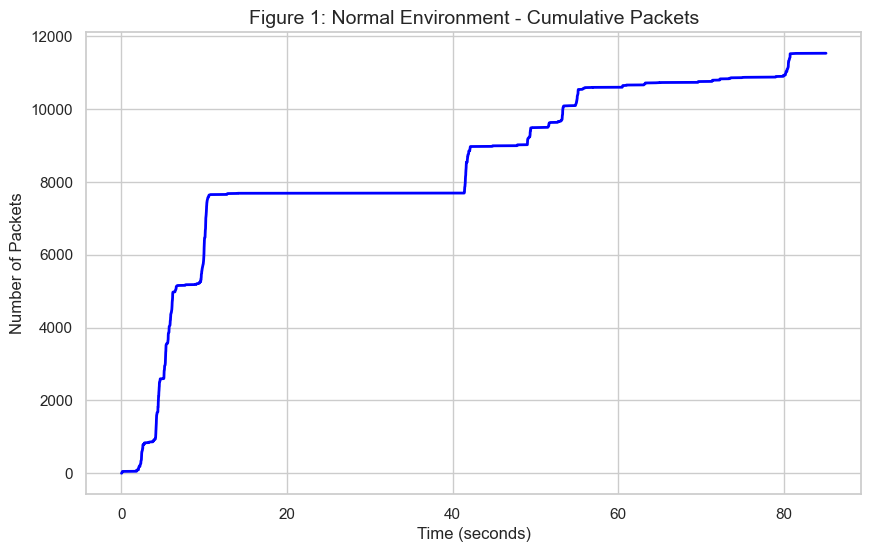

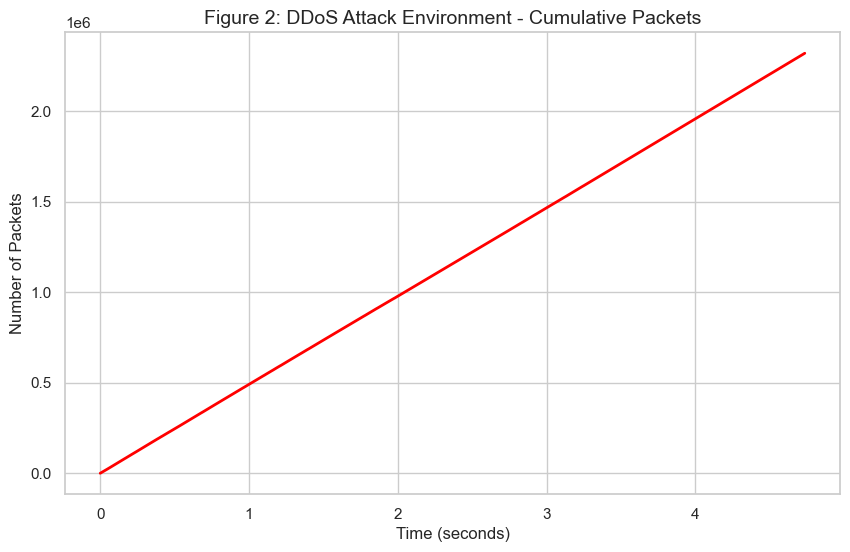

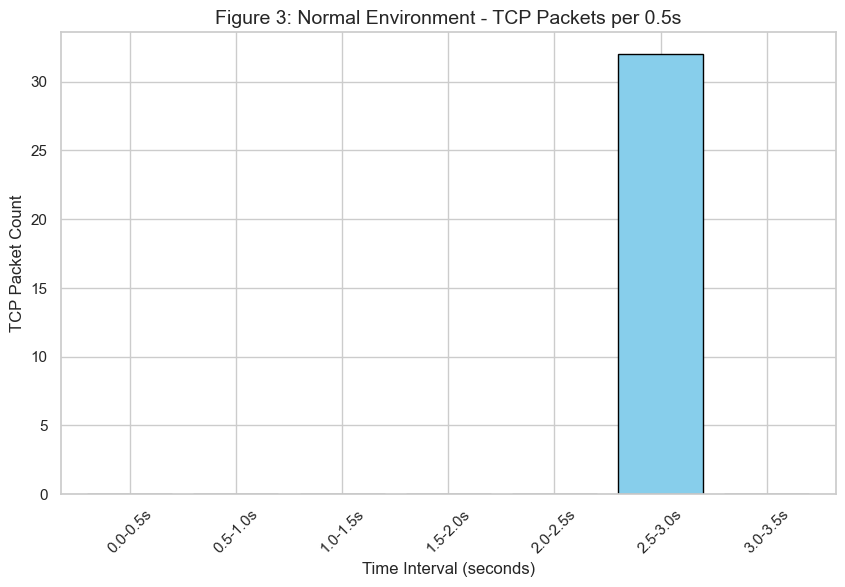

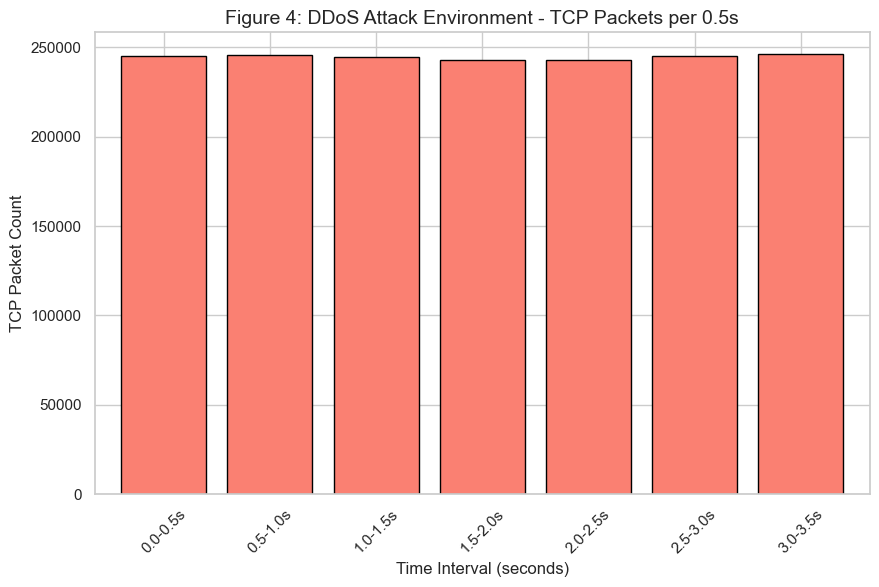

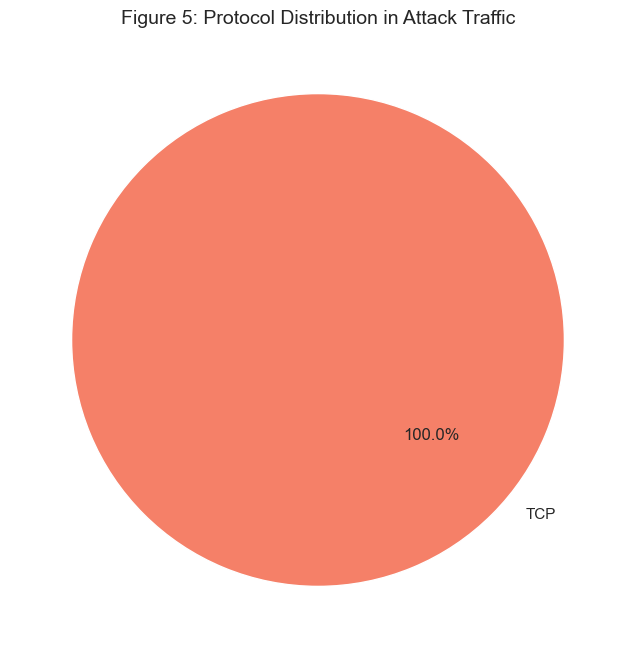

C:\Users\kenny\AppData\Local\Temp\ipykernel_6920\3036748243.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Normal', 'Attack'], y=[unique_ips_normal, unique_ips_attack], palette=['blue', 'red'])


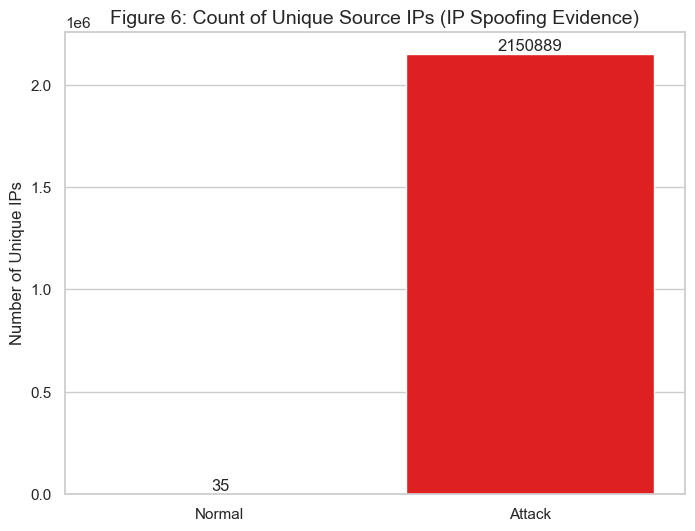

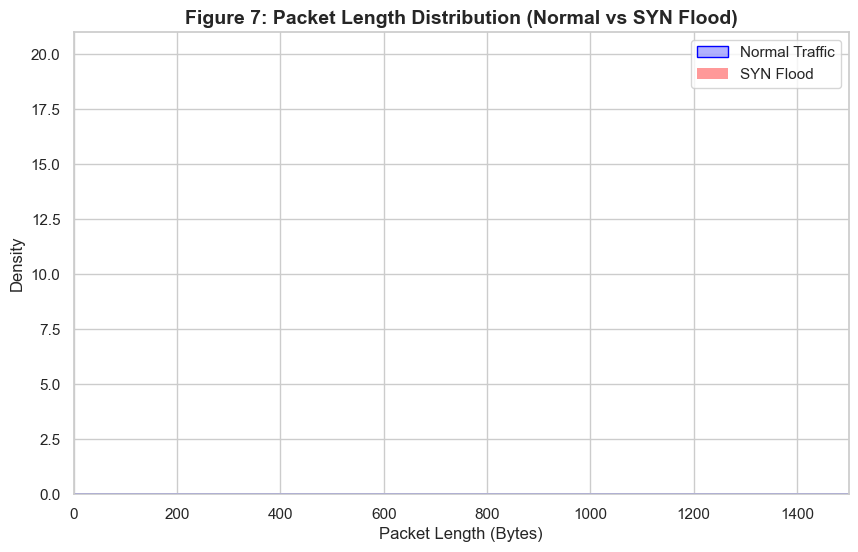

Normal variance: 8391761.65843316
Attack variance: 0.0
df_normal shape: (11534, 7)
df_attack shape: (2320270, 7)
normal Length head: 0      76
1      76
2     101
3      92
4    1294
Name: Length, dtype: int64
attack Length head: 0    54
1    54
2    54
3    54
4    54
Name: Length, dtype: int64
normal columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']
attack columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']


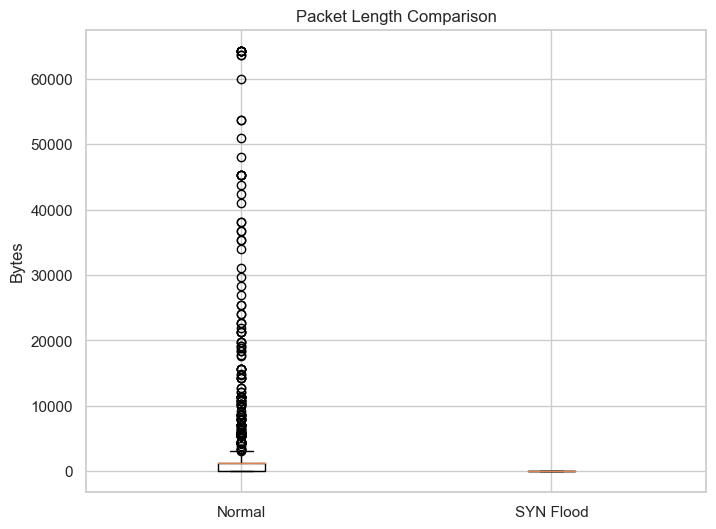

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 設定圖表風格，讓報告看起來更專業
sns.set(style="whitegrid")

# ==========================================
# ⚠️ 請在此處填寫您的真實檔案名稱
# ==========================================
normal_file = 'normal.csv'   # 正常流量檔名
attack_file = 'ddos_syn_flood_lo.csv'   # 攻擊流量檔名

def load_and_process(filename):
    try:
        df = pd.read_csv(filename)
        # 強制轉型，避免資料錯誤
        df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
        df['No.'] = pd.to_numeric(df['No.'], errors='coerce')
        return df
    except FileNotFoundError:
        print(f"錯誤: 找不到檔案 {filename}")
        return None

# 讀取資料
df_normal = load_and_process(normal_file)
df_attack = load_and_process(attack_file)

print("資料讀取完成！請繼續執行下方的繪圖程式碼。")

# --------------------------------------------------------------------------------
# 圖 1：正常環境 - 封包累積折線圖 (Normal Line Chart)
# 這張圖顯示正常情況下，封包數量隨時間的增長是非常緩慢平穩的。
# 繪製圖 1
plt.figure(figsize=(10, 6)) # 設定圖片大小

if df_normal is not None:
    plt.plot(df_normal['Time'], df_normal['No.'], color='blue', linewidth=2)
    plt.title('Figure 1: Normal Environment - Cumulative Packets', fontsize=14)
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Number of Packets', fontsize=12)
    plt.grid(True)
    plt.show()

# --------------------------------------------------------------------------------
# 圖 2：DDoS 攻擊環境 - 封包累積折線圖 (Attack Line Chart)
# 這張圖顯示攻擊時，封包數量在短時間內直線飆升（斜率極高），證明流量暴增。
# 繪製圖 2
plt.figure(figsize=(10, 6))

if df_attack is not None:
    plt.plot(df_attack['Time'], df_attack['No.'], color='red', linewidth=2)
    plt.title('Figure 2: DDoS Attack Environment - Cumulative Packets', fontsize=14)
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Number of Packets', fontsize=12)
    plt.grid(True)
    plt.show()

# --------------------------------------------------------------------------------
# 圖 3：正常環境 - TCP 封包柱狀圖 (Normal Bar Chart)
# 這張圖顯示每 0.5 秒內的 TCP 封包數量。正常情況下，柱子應該很矮，甚至某些區間是空的。
# 繪製圖 3
plt.figure(figsize=(10, 6))

if df_normal is not None:
    # 篩選 TCP 封包
    tcp_df = df_normal[df_normal['Protocol'] == 'TCP'].copy()
    
    # 設定時間區間 (每 0.5 秒)
    max_time = df_normal['Time'].max()
    bins = np.arange(0, max_time + 1, 0.5)
    
    # 統計數量
    time_groups = pd.cut(tcp_df['Time'], bins=bins)
    counts = time_groups.value_counts().sort_index()
    
    # 只取前 7 個區間 (0~3.5秒) 來畫，符合題目要求
    counts.head(7).plot(kind='bar', color='skyblue', edgecolor='black', width=0.8)
    
    plt.title('Figure 3: Normal Environment - TCP Packets per 0.5s', fontsize=14)
    plt.xlabel('Time Interval (seconds)', fontsize=12)
    plt.ylabel('TCP Packet Count', fontsize=12)
    
    # 修改 X 軸標籤格式
    labels = [f"{b.left:.1f}-{b.right:.1f}s" for b in counts.head(7).index]
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
    
    plt.show()

# --------------------------------------------------------------------------------
# 圖 4：DDoS 攻擊環境 - TCP 封包柱狀圖 (Attack Bar Chart)
# 這張圖會顯示每 0.5 秒都有巨量的 TCP 封包（因為是 SYN Flood），柱子會非常高。
# 繪製圖 4
plt.figure(figsize=(10, 6))

if df_attack is not None:
    # 篩選 TCP 封包
    tcp_df = df_attack[df_attack['Protocol'] == 'TCP'].copy()
    
    # 設定時間區間
    max_time = df_attack['Time'].max()
    bins = np.arange(0, max_time + 1, 0.5)
    
    # 統計數量
    time_groups = pd.cut(tcp_df['Time'], bins=bins)
    counts = time_groups.value_counts().sort_index()
    
    # 取前 7 個區間
    counts.head(7).plot(kind='bar', color='salmon', edgecolor='black', width=0.8)
    
    plt.title('Figure 4: DDoS Attack Environment - TCP Packets per 0.5s', fontsize=14)
    plt.xlabel('Time Interval (seconds)', fontsize=12)
    plt.ylabel('TCP Packet Count', fontsize=12)
    
    labels = [f"{b.left:.1f}-{b.right:.1f}s" for b in counts.head(7).index]
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
    
    plt.show()

# --------------------------------------------------------------------------------
# 加分項目：進階分析圖表 (Advanced Analysis)
# 這些圖可以用在報告的「結果分析」部分，證明你有做深入研究（來源 IP 偽造與協定單一性）。
# 圖 5：攻擊流量的協定分佈 (圓餅圖) 這張圖證明攻擊流量幾乎 100% 都是 TCP，符合 SYN Flood 特徵。
# 繪製圖 5 (進階分析 - 協定佔比)
plt.figure(figsize=(8, 8))

if df_attack is not None:
    protocol_counts = df_attack['Protocol'].value_counts().head(5)
    plt.pie(protocol_counts, labels=protocol_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Reds_d"))
    plt.title('Figure 5: Protocol Distribution in Attack Traffic', fontsize=14)
    plt.show()
    
# 圖 6：來源 IP 數量比較 (柱狀圖) 這張圖證明攻擊使用了 IP Spoofing（偽造 IP），導致 Attack 的來源 IP 數量遠多於 Normal。
# 繪製圖 6 (進階分析 - 來源 IP 數量)
plt.figure(figsize=(8, 6))

if df_normal is not None and df_attack is not None:
    unique_ips_normal = df_normal['Source'].nunique()
    unique_ips_attack = df_attack['Source'].nunique()
    
    sns.barplot(x=['Normal', 'Attack'], y=[unique_ips_normal, unique_ips_attack], palette=['blue', 'red'])
    plt.title('Figure 6: Count of Unique Source IPs (IP Spoofing Evidence)', fontsize=14)
    plt.ylabel('Number of Unique IPs', fontsize=12)
    
    # 標上數字
    plt.text(0, unique_ips_normal, f'{unique_ips_normal}', ha='center', va='bottom', fontsize=12)
    plt.text(1, unique_ips_attack, f'{unique_ips_attack}', ha='center', va='bottom', fontsize=12)
    
    plt.show()
    
    
# ==========================================
# 圖 7：封包大小分佈 (Packet Length Density)
# 目的：證明攻擊是機械化的固定小封包 (SYN)，而非正常人類行為
# ==========================================
# 繪製圖 7
plt.figure(figsize=(10,6))

# Normal KDE
sns.kdeplot(df_normal['Length'], 
            label='Normal Traffic',
            color='blue',
            fill=True,
            alpha=0.3)

# Attack histogram instead of KDE
sns.histplot(df_attack['Length'], 
             label='SYN Flood',
             color='red',
             bins=20,
             stat='density',
             alpha=0.4)

plt.title('Figure 7: Packet Length Distribution (Normal vs SYN Flood)', 
          fontsize=14, fontweight='bold')

plt.xlabel('Packet Length (Bytes)')
plt.ylabel('Density')
plt.xlim(0,1500)
plt.legend()
plt.grid(True)
plt.show()

print("Normal variance:", df_normal['Length'].var())
print("Attack variance:", df_attack['Length'].var())

print("df_normal shape:", df_normal.shape)
print("df_attack shape:", df_attack.shape)

print("normal Length head:", df_normal.get('Length', 'NO Length column').head())
print("attack Length head:", df_attack.get('Length', 'NO Length column').head())

# 檢查是否有 Length 欄
print("normal columns:", list(df_normal.columns)[:20])
print("attack columns:", list(df_attack.columns)[:20])


plt.figure(figsize=(8,6))

data = [df_normal['Length'], df_attack['Length']]
plt.boxplot(data, labels=['Normal','SYN Flood'])

plt.title("Packet Length Comparison")
plt.ylabel("Bytes")
plt.show()